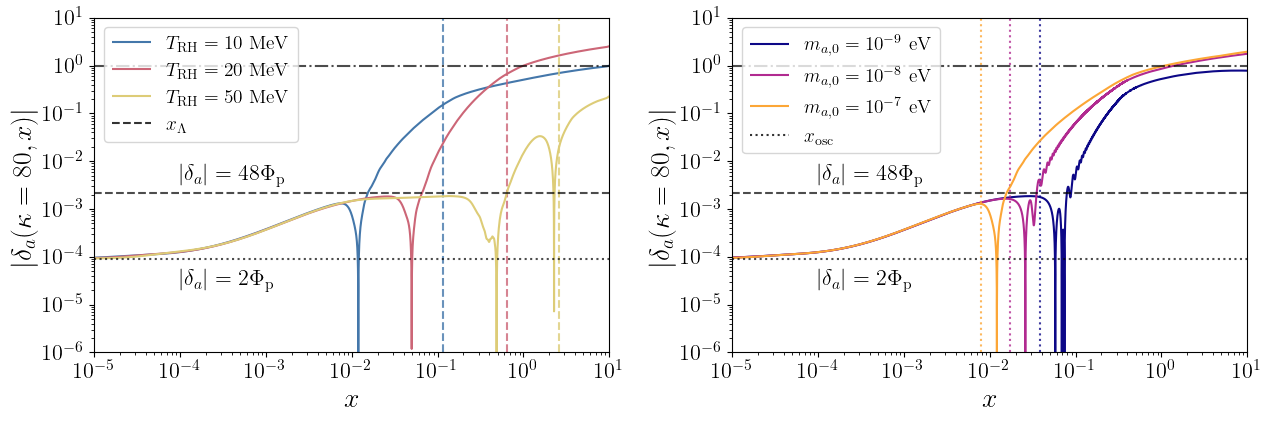

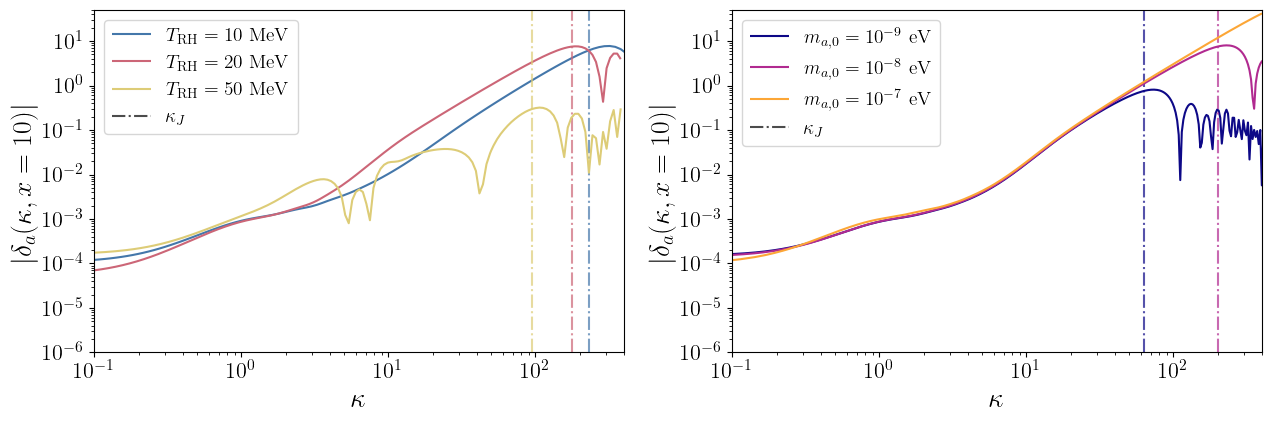

In [7]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import cblind as cb

def load_tend_data(base_path):
    data_dict = {}
    file_paths = glob.glob(os.path.join(base_path, "**", "axion_Tend_*.npz"), recursive=True)
    
    for file_path in file_paths:
        with np.load(file_path, allow_pickle=True) as data:
            bg = data['background'].item()
            axi_perts = data['axiPerts'].item()
            sf = data['scale_factors'].item()
            horiz = data['horizon'].item()
            inputs = data['inputs'].item()
            
            tend_val = inputs['Tend']
            
            data_dict[tend_val] = {
                "R": bg['R'],
                "delta_a_s": np.array(axi_perts['delta_a_s']),
                "R_RH": sf['R_RH'],
                "R_osc": sf['R_osc'],
                "R_l": sf['R_l'],
                "k_vals": horiz['k_vals'],
                "k_RH": horiz['k_RH'],
                "k_J": inputs['k_J'],
            }
            
    return dict(sorted(data_dict.items()))

def load_ma0_data(base_path):
    extracted_data = {}
    axion_files = glob.glob(os.path.join(base_path, "**", "axion_Tend_*.npz"), recursive=True)
    
    for axion_file in axion_files:
        if "1.00e-10" in axion_file:
            continue
            
        folder = os.path.dirname(axion_file)
        
        if "_V2" in axion_file:
            bg_files = glob.glob(os.path.join(folder, "noax_background_*_V2.npz"))
        else:
            bg_files = [f for f in glob.glob(os.path.join(folder, "noax_background_*.npz")) if "_V2" not in f]
            
        if not bg_files:
            continue
            
        with np.load(bg_files[0], allow_pickle=True) as prep:
            bg_data = prep['background'].item()
            mode_info = prep['modes'].item()
            horizon_info = prep['horizon'].item()
            
            r_val = bg_data['R']
            r_rh = mode_info['R_RH']
            k_rh = mode_info['k_RH'] 
            k_values = horizon_info['k_vals']
            
        with np.load(axion_file, allow_pickle=True) as ax:
            axi_perts = ax['axiPerts'].item()
            inputs = ax['inputs'].item()
            scale_factors = ax['scale_factors'].item()
            
            delta_a = axi_perts['delta_a_r'] 
            ma0_val = inputs['MA0']
            k_j_val = inputs['k_J']
            r_osc = scale_factors['R_osc']
            r_l_val = scale_factors['R_l']
            
        key = float(ma0_val)
        extracted_data[key] = {
            "delta_a": delta_a,
            "R": r_val,
            "R_RH": r_rh,
            "k_RH": k_rh, 
            "k_J": k_j_val,
            "k_values": k_values, 
            "R_osc": r_osc,
            "R_l": r_l_val,
        }
        
    return dict(sorted(extracted_data.items()))

tend_data = load_tend_data("Varying_Tend_fig8")
exclude_tend = [0.005, 0.030]
tend_data = {k: v for k, v in tend_data.items() if not any(np.isclose(k, e) for e in exclude_tend)}

ma0_data = load_ma0_data("Varying_MA0_fig8")

kappa_target = 80
phi_p = np.sqrt(2.101 * 10**(-9))
delta_a_i = 2 * phi_p
delta_a_f = 1
delta_a_r = 2 * (24 * phi_p)

plt.rcParams.update({
    "pdf.fonttype": 42,  
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}",
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

label_x = r'$x$'
label_kappa = r'$\kappa$'
label_delta_a_evol = rf'$|\delta_a(\kappa={kappa_target},x)|$'
label_delta_a_spec = r'$|\delta_a(\kappa,x=10)|$' 

colors_tend, _ = cb.Colorplots().cblind(len(tend_data))
colors_ma0 = plt.cm.plasma(np.linspace(0.0, 0.80, max(1, len(ma0_data))))

box_style = dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="silver", alpha=0.85)

os.makedirs("Plots", exist_ok=True)
os.makedirs("Plots/ALP_perturbations/ALP_delta_a", exist_ok=True)

fig_evol, (ax_evol_tend, ax_evol_ma0) = plt.subplots(1, 2, figsize=(13, 4.5))

for i, (tend_val, data) in enumerate(tend_data.items()):
    x_array = data["R"] / data["R_RH"]
    kappa_array = data["k_vals"] / data["k_RH"]
    
    idx_kappa = np.argmin(np.abs(kappa_array - kappa_target))
    delta_a_evol = np.abs(data["delta_a_s"][idx_kappa, :])
    
    tend_mev = tend_val * 1000
    current_color = colors_tend[i]
    label_tend = rf'$T_{{\mathrm{{RH}}}} = {tend_mev:.0f}$ MeV'
    
    ax_evol_tend.loglog(x_array, delta_a_evol, color=current_color, label=label_tend)
    
    x_l = data["R_l"] / data["R_RH"]
    ax_evol_tend.axvline(x_l, color=current_color, linestyle='--', alpha=0.8)

ax_evol_tend.plot([], [], color='black', linestyle='--', alpha=0.8, label=r'$x_\Lambda$')

for i, (ma0_val, data) in enumerate(ma0_data.items()):
    x_array = data["R"] / data["R_RH"]
    kappa_array = data["k_values"] / data["k_RH"]
    
    idx_kappa = np.argmin(np.abs(kappa_array - kappa_target))
    delta_a_evol = np.abs(np.array(data["delta_a"])[idx_kappa, :])
    
    ma0_ev = ma0_val * 1e9
    exponent = int(np.round(np.log10(ma0_ev))) if ma0_ev > 0 else 0
    current_color = colors_ma0[i]
    label_ma0 = rf'$m_{{a,0}} = 10^{{{exponent}}}$ eV'
    
    ax_evol_ma0.loglog(x_array, delta_a_evol, color=current_color, label=label_ma0)
    
    x_osc = data["R_osc"] / data["R_RH"]
    ax_evol_ma0.axvline(x_osc, color=current_color, linestyle=':', alpha=0.8)

ax_evol_ma0.plot([], [], color='black', linestyle=':', alpha=0.8, label=r'$x_{\mathrm{osc}}$')

for ax in [ax_evol_tend, ax_evol_ma0]:
    ax.axhline(delta_a_i, color='black', linestyle=':', alpha=0.7)
    ax.text(1e-4, delta_a_i / 5, r'$|\delta_a| = 2\Phi_{\mathrm{p}}$', color='black', va='bottom')

    ax.axhline(delta_a_f, color='black', linestyle='-.', alpha=0.7)
    #ax.text(7e-3, delta_a_f * 1.8, r'$|\delta_a|= 1$', color='black', va='bottom')

    ax.axhline(delta_a_r, color='black', linestyle='--', alpha=0.7)
    ax.text(1e-4, delta_a_r * 1.3, r'$|\delta_a|=48\Phi_{\mathrm{p}}$', color='black', va='bottom')

    ax.set_xlabel(label_x)
    ax.set_ylabel(label_delta_a_evol)
    ax.set_xlim(1e-5, 1e1)
    ax.set_ylim(1e-6, 1e1)
    ax.legend(loc='upper left')

fig_evol.tight_layout()
fig_evol.savefig("Plots/ALP_perturbations/ALP_delta_a/Modes_delta_a_axion.pdf", bbox_inches='tight', dpi=300)


fig_spec, (ax_spec_tend, ax_spec_ma0) = plt.subplots(1, 2, figsize=(13, 4.5))

for i, (tend_val, data) in enumerate(tend_data.items()):
    kappa_array = data["k_vals"] / data["k_RH"]
    delta_a_final = np.abs(data["delta_a_s"][:, -1])
    
    tend_mev = tend_val * 1000
    current_color = colors_tend[i]
    label_tend = rf'$T_{{\mathrm{{RH}}}} = {tend_mev:.0f}$ MeV'
    
    ax_spec_tend.plot(kappa_array, delta_a_final, color=current_color, label=label_tend)
    
    k_j_val = data["k_J"][-1] if isinstance(data["k_J"], np.ndarray) else data["k_J"]
    kappa_j = k_j_val / data["k_RH"]
    ax_spec_tend.axvline(kappa_j, color=current_color, linestyle='-.', alpha=0.7)

for i, (ma0_val, data) in enumerate(ma0_data.items()):
    kappa_array = data["k_values"] / data["k_RH"]
    delta_a_final = np.abs(np.array(data["delta_a"])[:, -1])
    
    ma0_ev = ma0_val * 1e9
    exponent = int(np.round(np.log10(ma0_ev))) if ma0_ev > 0 else 0
    current_color = colors_ma0[i]
    label_ma0 = rf'$m_{{a,0}} = 10^{{{exponent}}}$ eV'
    
    ax_spec_ma0.plot(kappa_array, delta_a_final, color=current_color, label=label_ma0)
    
    k_j_val = data["k_J"][-1] if isinstance(data["k_J"], np.ndarray) else data["k_J"]
    kappa_j = k_j_val / data["k_RH"]
    ax_spec_ma0.axvline(kappa_j, color=current_color, linestyle='-.', alpha=0.7)

for ax in [ax_spec_tend, ax_spec_ma0]:
    ax.plot([], [], color='black', linestyle='-.', alpha=0.7, label=r'$\kappa_J$')
    
    ax.set_xlabel(label_kappa)
    ax.set_ylabel(label_delta_a_spec)
    ax.set_xlim(1e-1, 4e2)
    ax.set_ylim(1e-6, 50)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(loc='upper left')

fig_spec.tight_layout()
fig_spec.savefig("Plots/ALP_perturbations/ALP_delta_a/Spectrums_delta_a.pdf", bbox_inches='tight', dpi=300)

plt.show()

### ONE MASS PLOT

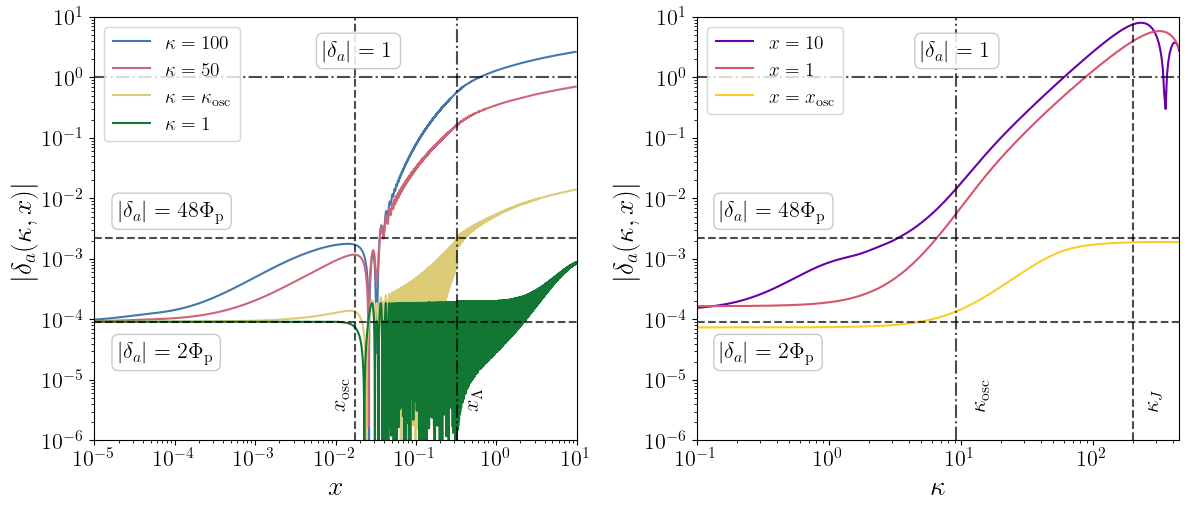

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

def load_target_data(base_path, target_mass):
    subfolders = glob.glob(os.path.join(base_path, "TRH_*"))
    for folder in subfolders:
        bg_files = glob.glob(os.path.join(folder, "noax_background_*.npz"))
        if not bg_files:
            continue
            
        with np.load(bg_files[0], allow_pickle=True) as prep:
            bg = prep['background'].item()
            modes = prep['modes'].item()
            horizon = prep['horizon'].item()

        ax_files = glob.glob(os.path.join(folder, f"*MA0_{target_mass:.2e}*.npz"))
        if not ax_files:
            continue
            
        with np.load(ax_files[0], allow_pickle=True) as ax:
            axi_perts = ax['axiPerts'].item()
            scale_factors = ax['scale_factors'].item()
            inputs = ax['inputs'].item()

        return {
            "R": bg["R"],
            "Hub": bg["Hub"],
            "k_vals": horizon["k_vals"],
            "k_RH": modes["k_RH"],
            "R_RH": modes["R_RH"],
            "delta_a": np.array(axi_perts["delta_a_r"]),
            "R_osc": scale_factors["R_osc"],
            "R_l": scale_factors["R_l"],
            "k_J": inputs["k_J"]
        }
    return None

data = load_target_data("Varying_MA0_fig8", 1e-8)

r_arr = data["R"]
hub_arr = data["Hub"]
k_vals = data["k_vals"]
k_rh = data["k_RH"]
r_rh = data["R_RH"]
delta_a_raw = np.abs(data["delta_a"])
r_osc = data["R_osc"]
r_l = data["R_l"]
k_j = data["k_J"]
delta_a = np.abs(data["delta_a"])
x_arr = r_arr / r_rh
kappa_arr = k_vals / k_rh
x_osc = r_osc / r_rh
x_l = r_l / r_rh
kappa_j = k_j / k_rh

f_hub = interp1d(r_arr, hub_arr, kind='cubic', fill_value="extrapolate")
hub_osc = f_hub(r_osc)
kappa_osc = (hub_osc * r_osc) / k_rh

plt.rcParams.update({
    "pdf.fonttype": 42,  
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}",
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

label_x = r'$x$'
label_kappa = r'$\kappa$'
label_delta = r'$|\delta_a(\kappa,x)|$'

fig, (ax_evol, ax_spec) = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={'wspace': 0.25})

box_style = dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="silver", alpha=0.85)

delta_i = 2 * phi_p
delta_r = 48 * phi_p
delta_f = 1

k_targets = [100, 50, kappa_osc, 1]
import cblind as cb
colors_k, _ = cb.Colorplots().cblind(len(k_targets))

for i, k_val in enumerate(k_targets):
    idx_k = np.argmin(np.abs(kappa_arr - k_val))
    da_evol = np.abs(delta_a[idx_k, :])
    if k_val == kappa_osc:
        ax_evol.loglog(x_arr, da_evol, color=colors_k[i], label=r'$\kappa = \kappa_{\mathrm{osc}}$')
    else:
        ax_evol.loglog(x_arr, da_evol, color=colors_k[i], label=rf'$\kappa = {k_val}$')

ax_evol.axhline(delta_i, color='black', linestyle='--', alpha=0.7)
ax_evol.text(2e-5, delta_i / 5, r'$|\delta_a| = 2\Phi_{\mathrm{p}}$', color='black', va='bottom')

ax_evol.axhline(delta_r, color='black', linestyle='--', alpha=0.7)
ax_evol.text(2e-5, delta_r * 1.8, r'$|\delta_a|=48\Phi_{\mathrm{p}}$', color='black', va='bottom')

ax_evol.axhline(delta_f, color='black', linestyle='-.', alpha=0.7)
ax_evol.text(7e-3, delta_f * 1.8, r'$|\delta_a|= 1$', color='black', va='bottom')



ax_evol.axvline(x_osc, color='black', linestyle='--', alpha=0.7)
ax_evol.text(x_osc / 2, 3e-6, r'$x_{\mathrm{osc}}$', color='black', rotation=90, va='bottom', ha='left')

ax_evol.axvline(x_l, color='black', linestyle='-.', alpha=0.7)
ax_evol.text(x_l * 1.2, 3e-6, r'$x_{\Lambda}$', color='black', rotation=90, va='bottom', ha='left')

ax_evol.set_xlabel(label_x)
ax_evol.set_ylabel(label_delta)
ax_evol.set_xlim(1e-5, 1e1)
ax_evol.set_ylim(1e-6, 1e1)
ax_evol.legend(loc='upper left')

x_targets = [10, 1, x_osc]
colors_x = plt.cm.plasma(np.linspace(0.2, 0.9, len(x_targets)))

for i, x_val in enumerate(x_targets):
    idx_x = np.argmin(np.abs(x_arr - x_val))
    da_spec = np.abs(delta_a[:, idx_x])
    if x_val == x_osc:
        ax_spec.plot(kappa_arr, da_spec, color=colors_x[i], label=r'$x = x_{\mathrm{osc}}$')
    else:
        ax_spec.plot(kappa_arr, da_spec, color=colors_x[i], label=rf'$x = {x_val}$')

ax_spec.axhline(delta_i, color='black', linestyle='--', alpha=0.7)
ax_spec.text(1.5e-1, delta_i / 5, r'$|\delta_a| = 2\Phi_{\mathrm{p}}$', color='black', va='bottom')

ax_spec.axhline(delta_r, color='black', linestyle='--', alpha=0.7)
ax_spec.text(1.5e-1, delta_r * 1.8, r'$|\delta_a|=48\Phi_{\mathrm{p}}$', color='black', va='bottom')

ax_spec.axhline(delta_f, color='black', linestyle='-.', alpha=0.7)
ax_spec.text(5e0, delta_f * 1.8, r'$|\delta_a|= 1$', color='black', va='bottom')

ax_spec.axvline(kappa_j, color='black', linestyle='--', alpha=0.7)
ax_spec.text(kappa_j * 1.2, 3e-6, r'$\kappa_J$', color='black', rotation=90, va='bottom', ha='left')

ax_spec.axvline(kappa_osc, color='black', linestyle='-.', alpha=0.7)
ax_spec.text(kappa_osc * 1.8, 3e-6, r'$\kappa_{\mathrm{osc}}$', color='black', rotation=90, va='bottom', ha='right')

ax_spec.set_xlabel(label_kappa)
ax_spec.set_ylabel(label_delta)
ax_spec.set_xlim(1e-1, kappa_arr[-1])
ax_spec.set_ylim(1e-6, 1e1)
ax_spec.set_xscale('log')
ax_spec.set_yscale('log')
ax_spec.legend(loc='upper left')

os.makedirs("Plots/ALP_perturbations", exist_ok=True)
fig.savefig("Plots/ALP_perturbations/ALP_overdensity_1e-8.pdf", bbox_inches='tight', dpi=300)

plt.show()

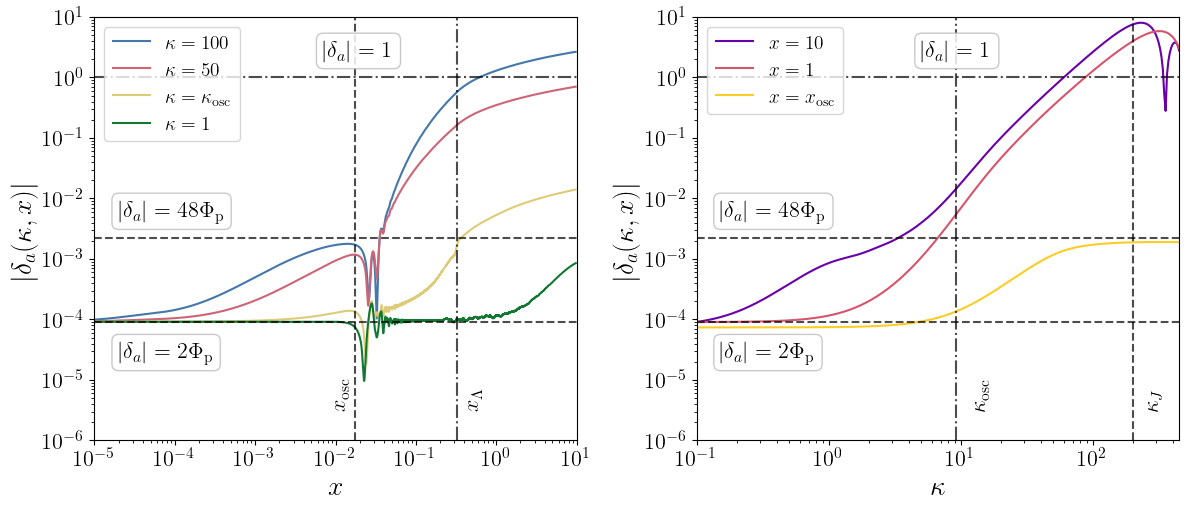

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

def load_target_data(base_path, target_mass):
    subfolders = glob.glob(os.path.join(base_path, "TRH_*"))
    for folder in subfolders:
        bg_files = glob.glob(os.path.join(folder, "noax_background_*.npz"))
        if not bg_files:
            continue
            
        with np.load(bg_files[0], allow_pickle=True) as prep:
            bg = prep['background'].item()
            modes = prep['modes'].item()
            horizon = prep['horizon'].item()

        ax_files = glob.glob(os.path.join(folder, f"*MA0_{target_mass:.2e}*.npz"))
        if not ax_files:
            continue
            
        with np.load(ax_files[0], allow_pickle=True) as ax:
            axi_perts = ax['axiPerts'].item()
            scale_factors = ax['scale_factors'].item()
            inputs = ax['inputs'].item()

        return {
            "R": bg["R"],
            "Hub": bg["Hub"],
            "k_vals": horizon["k_vals"],
            "k_RH": modes["k_RH"],
            "R_RH": modes["R_RH"],
            "delta_a": np.array(axi_perts["delta_a_r"]),
            "R_osc": scale_factors["R_osc"],
            "R_l": scale_factors["R_l"],
            "k_J": inputs["k_J"]
        }
    return None

def apply_log_savgol(x_arr, y_arr, window_len=500, poly_order=2):
    valid_mask = x_arr > 0
    x_val = x_arr[valid_mask]
    y_val = y_arr[valid_mask]
    
    log_x = np.log(x_val)
    log_x_unif = np.linspace(log_x[0], log_x[-1], len(x_val))
    
    f_in = interp1d(log_x, y_val, kind='linear', fill_value="extrapolate")
    y_unif = f_in(log_x_unif)
    
    if len(y_unif) < window_len:
        window_len = len(y_unif) // 2 * 2 + 1
        
    y_smooth_unif = savgol_filter(y_unif, window_len, poly_order)
    
    f_out = interp1d(log_x_unif, y_smooth_unif, kind='cubic', fill_value="extrapolate")
    y_smooth = f_out(log_x)
    
    out = np.copy(y_arr)
    out[valid_mask] = y_smooth
    return np.abs(out)

data = load_target_data("Varying_MA0_fig8", 1e-8)

r_arr = data["R"]
hub_arr = data["Hub"]
k_vals = data["k_vals"]
k_rh = data["k_RH"]
r_rh = data["R_RH"]
r_osc = data["R_osc"]
r_l = data["R_l"]
k_j = data["k_J"]

delta_a_raw = np.abs(data["delta_a"])
phi_p = np.sqrt(2.101 * 10**(-9))

x_arr = r_arr / r_rh
kappa_arr = k_vals / k_rh
x_osc = r_osc / r_rh
x_l = r_l / r_rh
kappa_j = k_j / k_rh

delta_a_smooth = np.zeros_like(delta_a_raw)
for idx_k in range(delta_a_raw.shape[0]):
    delta_a_smooth[idx_k, :] = apply_log_savgol(x_arr, delta_a_raw[idx_k, :])

f_hub = interp1d(r_arr, hub_arr, kind='cubic', fill_value="extrapolate")
hub_osc = f_hub(r_osc)
kappa_osc = (hub_osc * r_osc) / k_rh

plt.rcParams.update({
    "pdf.fonttype": 42,  
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}",
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

label_x = r'$x$'
label_kappa = r'$\kappa$'
label_delta = r'$|\delta_a(\kappa,x)|$'

fig, (ax_evol, ax_spec) = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={'wspace': 0.25})

box_style = dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="silver", alpha=0.85)

delta_i = 2 * phi_p
delta_r = 48 * phi_p
delta_f = 1

k_targets = [100, 50, kappa_osc, 1]
import cblind as cb
colors_k, _ = cb.Colorplots().cblind(len(k_targets))

for i, k_val in enumerate(k_targets):
    idx_k = np.argmin(np.abs(kappa_arr - k_val))
    da_evol = delta_a_smooth[idx_k, :]
    if k_val == kappa_osc:
        ax_evol.loglog(x_arr, da_evol, color=colors_k[i], label=r'$\kappa = \kappa_{\mathrm{osc}}$')
    else:
        ax_evol.loglog(x_arr, da_evol, color=colors_k[i], label=rf'$\kappa = {k_val}$')

ax_evol.axhline(delta_i, color='black', linestyle='--', alpha=0.7)
ax_evol.text(2e-5, delta_i / 5, r'$|\delta_a| = 2\Phi_{\mathrm{p}}$', color='black', va='bottom')

ax_evol.axhline(delta_r, color='black', linestyle='--', alpha=0.7)
ax_evol.text(2e-5, delta_r * 1.8, r'$|\delta_a|=48\Phi_{\mathrm{p}}$', color='black', va='bottom')

#ax_evol.axhline(delta_f, color='black', linestyle='-.', alpha=0.7)
#ax_evol.text(7e-3, delta_f * 1.8, r'$|\delta_a|= 1$', color='black', va='bottom', bbox=box_style)



ax_evol.axvline(x_osc, color='black', linestyle='--', alpha=0.7)
ax_evol.text(x_osc / 2, 3e-6, r'$x_{\mathrm{osc}}$', color='black', rotation=90, va='bottom', ha='left')

ax_evol.axvline(x_l, color='black', linestyle='-.', alpha=0.7)
ax_evol.text(x_l * 1.2, 3e-6, r'$x_{\Lambda}$', color='black', rotation=90, va='bottom', ha='left')

ax_evol.set_xlabel(label_x)
ax_evol.set_ylabel(label_delta)
ax_evol.set_xlim(1e-5, 1e1)
ax_evol.set_ylim(1e-6, 1e1)
ax_evol.legend(loc='upper left')

x_targets = [10, 1, x_osc]
colors_x = plt.cm.plasma(np.linspace(0.2, 0.9, len(x_targets)))

for i, x_val in enumerate(x_targets):
    idx_x = np.argmin(np.abs(x_arr - x_val))
    da_spec = delta_a_smooth[:, idx_x]
    if x_val == x_osc:
        ax_spec.plot(kappa_arr, da_spec, color=colors_x[i], label=r'$x = x_{\mathrm{osc}}$')
    else:
        ax_spec.plot(kappa_arr, da_spec, color=colors_x[i], label=rf'$x = {x_val}$')

ax_spec.axhline(delta_i, color='black', linestyle='--', alpha=0.7)
ax_spec.text(1.5e-1, delta_i / 5, r'$|\delta_a| = 2\Phi_{\mathrm{p}}$', color='black', va='bottom')

ax_spec.axhline(delta_r, color='black', linestyle='--', alpha=0.7)
ax_spec.text(1.5e-1, delta_r * 1.8, r'$|\delta_a|=48\Phi_{\mathrm{p}}$', color='black', va='bottom')

#ax_spec.axhline(delta_f, color='black', linestyle='-.', alpha=0.7)
#ax_spec.text(5e0, delta_f * 1.8, r'$|\delta_a|= 1$', color='black', va='bottom', bbox=box_style)

ax_spec.axvline(kappa_j, color='black', linestyle='--', alpha=0.7)
ax_spec.text(kappa_j * 1.2, 3e-6, r'$\kappa_J$', color='black', rotation=90, va='bottom', ha='left')

ax_spec.axvline(kappa_osc, color='black', linestyle='-.', alpha=0.7)
ax_spec.text(kappa_osc * 1.8, 3e-6, r'$\kappa_{\mathrm{osc}}$', color='black', rotation=90, va='bottom', ha='right')

ax_spec.set_xlabel(label_kappa)
ax_spec.set_ylabel(label_delta)
ax_spec.set_xlim(1e-1, kappa_arr[-1])
ax_spec.set_ylim(1e-6, 1e1)
ax_spec.set_xscale('log')
ax_spec.set_yscale('log')
ax_spec.legend(loc='upper left')

os.makedirs("Plots/ALP_perturbations", exist_ok=True)
fig.savefig("Plots/ALP_perturbations/ALP_overdensity_1e-8.pdf", bbox_inches='tight', dpi=300)

plt.show()

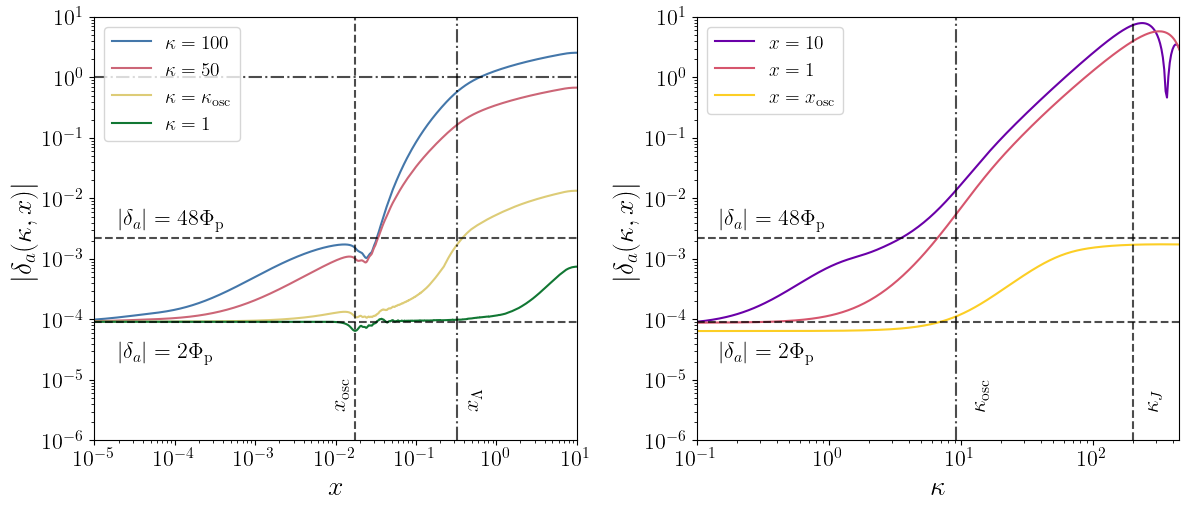

In [10]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.ndimage import uniform_filter1d

def load_target_data(base_path, target_mass):
    subfolders = glob.glob(os.path.join(base_path, "TRH_*"))
    for folder in subfolders:
        bg_files = glob.glob(os.path.join(folder, "noax_background_*.npz"))
        if not bg_files:
            continue
            
        with np.load(bg_files[0], allow_pickle=True) as prep:
            bg = prep['background'].item()
            modes = prep['modes'].item()
            horizon = prep['horizon'].item()

        ax_files = glob.glob(os.path.join(folder, f"*MA0_{target_mass:.2e}*.npz"))
        if not ax_files:
            continue
            
        with np.load(ax_files[0], allow_pickle=True) as ax:
            axi_perts = ax['axiPerts'].item()
            scale_factors = ax['scale_factors'].item()
            inputs = ax['inputs'].item()

        return {
            "R": bg["R"],
            "Hub": bg["Hub"],
            "k_vals": horizon["k_vals"],
            "k_RH": modes["k_RH"],
            "R_RH": modes["R_RH"],
            "delta_a": np.array(axi_perts["delta_a_r"]),
            "R_osc": scale_factors["R_osc"],
            "R_l": scale_factors["R_l"],
            "k_J": inputs["k_J"]
        }
    return None

def apply_log_average(x_arr, y_arr, window_len=4500):
    valid_mask = x_arr > 0
    x_val = x_arr[valid_mask]
    y_val = np.abs(y_arr[valid_mask])
    
    log_x = np.log(x_val)
    num_points = max(len(x_val), 100000)
    log_x_unif = np.linspace(log_x[0], log_x[-1], num_points)
    
    f_in = interp1d(log_x, y_val, kind='linear', fill_value="extrapolate")
    y_unif = f_in(log_x_unif)
    
    if len(y_unif) < window_len:
        window_len = len(y_unif) // 2 * 2 + 1
        
    y_smooth_unif = uniform_filter1d(y_unif, size=window_len)
    
    f_out = interp1d(log_x_unif, y_smooth_unif, kind='linear', fill_value="extrapolate")
    y_smooth = f_out(log_x)
    
    out = np.copy(np.abs(y_arr))
    out[valid_mask] = y_smooth
    return out

data = load_target_data("Varying_MA0_fig8", 1e-8)

r_arr = data["R"]
hub_arr = data["Hub"]
k_vals = data["k_vals"]
k_rh = data["k_RH"]
r_rh = data["R_RH"]
r_osc = data["R_osc"]
r_l = data["R_l"]
k_j = data["k_J"]

delta_a_raw = np.abs(data["delta_a"])
phi_p = np.sqrt(2.101 * 10**(-9))

x_arr = r_arr / r_rh
kappa_arr = k_vals / k_rh
x_osc = r_osc / r_rh
x_l = r_l / r_rh
kappa_j = k_j / k_rh

delta_a_smooth = np.zeros_like(delta_a_raw)
for idx_k in range(delta_a_raw.shape[0]):
    delta_a_smooth[idx_k, :] = apply_log_average(x_arr, delta_a_raw[idx_k, :])

f_hub = interp1d(r_arr, hub_arr, kind='cubic', fill_value="extrapolate")
hub_osc = f_hub(r_osc)
kappa_osc = (hub_osc * r_osc) / k_rh

plt.rcParams.update({
    "pdf.fonttype": 42,  
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}",
    "font.family": "serif",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

label_x = r'$x$'
label_kappa = r'$\kappa$'
label_delta = r'$|\delta_a(\kappa,x)|$'

fig, (ax_evol, ax_spec) = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={'wspace': 0.25})

box_style = dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="silver", alpha=0.85)

delta_i = 2 * phi_p
delta_r = 48 * phi_p
delta_f = 1

k_targets = [100, 50, kappa_osc, 1]
import cblind as cb
colors_k, _ = cb.Colorplots().cblind(len(k_targets))

for i, k_val in enumerate(k_targets):
    idx_k = np.argmin(np.abs(kappa_arr - k_val))
    da_evol = delta_a_smooth[idx_k, :]
    if k_val == kappa_osc:
        ax_evol.loglog(x_arr, da_evol, color=colors_k[i], linestyle='-', label=r'$\kappa = \kappa_{\mathrm{osc}}$')
    else:
        ax_evol.loglog(x_arr, da_evol, color=colors_k[i], linestyle='-', label=rf'$\kappa = {k_val}$')

ax_evol.axhline(delta_i, color='black', linestyle='--', alpha=0.7)
ax_evol.text(2e-5, delta_i / 5, r'$|\delta_a| = 2\Phi_{\mathrm{p}}$', color='black', va='bottom')

ax_evol.axhline(delta_r, color='black', linestyle='--', alpha=0.7)
ax_evol.text(2e-5, delta_r * 1.3, r'$|\delta_a|=48\Phi_{\mathrm{p}}$', color='black', va='bottom')

ax_evol.axhline(delta_f, color='black', linestyle='-.', alpha=0.7)
#ax_evol.text(7e-3, delta_f * 1.8, r'$|\delta_a|= 1$', color='black', va='bottom', bbox=box_style)

ax_evol.axvline(x_osc, color='black', linestyle='--', alpha=0.7)
ax_evol.text(x_osc / 2, 3e-6, r'$x_{\mathrm{osc}}$', color='black', rotation=90, va='bottom', ha='left')

ax_evol.axvline(x_l, color='black', linestyle='-.', alpha=0.7)
ax_evol.text(x_l * 1.2, 3e-6, r'$x_{\Lambda}$', color='black', rotation=90, va='bottom', ha='left')

ax_evol.set_xlabel(label_x)
ax_evol.set_ylabel(label_delta)
ax_evol.set_xlim(1e-5, 1e1)
ax_evol.set_ylim(1e-6, 1e1)
ax_evol.legend(loc='upper left')

x_targets = [10, 1, x_osc]
colors_x = plt.cm.plasma(np.linspace(0.2, 0.9, len(x_targets)))

for i, x_val in enumerate(x_targets):
    idx_x = np.argmin(np.abs(x_arr - x_val))
    da_spec = delta_a_smooth[:, idx_x]
    if x_val == x_osc:
        ax_spec.plot(kappa_arr, da_spec, color=colors_x[i], linestyle='-', label=r'$x = x_{\mathrm{osc}}$')
    else:
        ax_spec.plot(kappa_arr, da_spec, color=colors_x[i], linestyle='-', label=rf'$x = {x_val}$')

ax_spec.axhline(delta_i, color='black', linestyle='--', alpha=0.7)
ax_spec.text(1.5e-1, delta_i / 5, r'$|\delta_a| = 2\Phi_{\mathrm{p}}$', color='black', va='bottom')

ax_spec.axhline(delta_r, color='black', linestyle='--', alpha=0.7)
ax_spec.text(1.5e-1, delta_r * 1.3, r'$|\delta_a|=48\Phi_{\mathrm{p}}$', color='black', va='bottom')

#ax_spec.axhline(delta_f, color='black', linestyle='-.', alpha=0.7)
#ax_spec.text(5e0, delta_f * 1.8, r'$|\delta_a|= 1$', color='black', va='bottom', bbox=box_style)

ax_spec.axvline(kappa_j, color='black', linestyle='--', alpha=0.7)
ax_spec.text(kappa_j * 1.2, 3e-6, r'$\kappa_J$', color='black', rotation=90, va='bottom', ha='left')

ax_spec.axvline(kappa_osc, color='black', linestyle='-.', alpha=0.7)
ax_spec.text(kappa_osc * 1.8, 3e-6, r'$\kappa_{\mathrm{osc}}$', color='black', rotation=90, va='bottom', ha='right')

ax_spec.set_xlabel(label_kappa)
ax_spec.set_ylabel(label_delta)
ax_spec.set_xlim(1e-1, kappa_arr[-1])
ax_spec.set_ylim(1e-6, 1e1)
ax_spec.set_xscale('log')
ax_spec.set_yscale('log')
ax_spec.legend(loc='upper left')

os.makedirs("Plots/ALP_perturbations", exist_ok=True)
fig.savefig("Plots/ALP_perturbations/ALP_overdensity_1e-8_av.pdf", bbox_inches='tight', dpi=300)

plt.show()